In [1]:
#Import packages
using Pkg, CSV, DataFrames, Statistics, Plots, Ipopt, Combinatorics, Distances, LinearAlgebra, AmplNLWriter, NBInclude, Gurobi, JuMP, Graphs, GraphRecipes

In [2]:
@nbinclude("Similarity Factor & Bid-Ask Prices Parameterized.ipynb")
@nbinclude("Cost Function Parameterized.ipynb")
@nbinclude("Penalty Function Parameterized.ipynb")
@nbinclude("Tabu List.ipynb")

In [3]:
#Read in asset-level prices
btcdf = CSV.read("btc_book-2024-08-01-trimmed.csv", DataFrame)
dgcdf = CSV.read("dgc_book-2024-08-01-trimmed.csv", DataFrame)
ltcdf = CSV.read("ltc_book-2024-08-01-trimmed.csv", DataFrame)
ethdf = CSV.read("eth_book-2024-08-01-trimmed.csv", DataFrame)

#trim dataframes for price/correlation variable calculation 
btcdf_trimmed = (select(btcdf,[:"best_bid_price",:"best_ask_price",:"best_ask_qty",:"best_bid_qty",:"event_time"]))[1:10,1:5]
ltcdf_trimmed = (select(ltcdf,[:"best_bid_price",:"best_ask_price",:"best_ask_qty",:"best_bid_qty",:"event_time"]))[1:10,1:5]
ethdf_trimmed = (select(ethdf,[:"best_bid_price",:"best_ask_price",:"best_ask_qty",:"best_bid_qty",:"event_time"]))[1:10,1:5]
dgcdf_trimmed = (select(dgcdf,[:"best_bid_price",:"best_ask_price",:"best_ask_qty",:"best_bid_qty",:"event_time"]))[1:10,1:5]

#Calculate weighted average price column between ask and bid
btcdf_trimmed[!, "total_quantity"] = btcdf_trimmed[!,"best_ask_qty"]+ btcdf_trimmed[!,"best_bid_qty"]
btcdf_trimmed[!, "weighted_avg_price"] = ((btcdf_trimmed[!,"best_ask_qty"].*btcdf_trimmed[!,"best_ask_price"]) + (btcdf_trimmed[!,"best_bid_qty"].*btcdf_trimmed[!,"best_bid_price"]))./btcdf_trimmed[!, "total_quantity"]

ethdf_trimmed[!, "total_quantity"] = ethdf_trimmed[!,"best_ask_qty"]+ ethdf_trimmed[!,"best_bid_qty"]
ethdf_trimmed[!, "weighted_avg_price"] = ((ethdf_trimmed[!,"best_ask_qty"].*ethdf_trimmed[!,"best_ask_price"]) + (ethdf_trimmed[!,"best_bid_qty"].*ethdf_trimmed[!,"best_bid_price"]))./ethdf_trimmed[!, "total_quantity"]

ltcdf_trimmed[!, "total_quantity"] = ltcdf_trimmed[!,"best_ask_qty"]+ ltcdf_trimmed[!,"best_bid_qty"]
ltcdf_trimmed[!, "weighted_avg_price"] = ((ltcdf_trimmed[!,"best_ask_qty"].*ltcdf_trimmed[!,"best_ask_price"]) + (ltcdf_trimmed[!,"best_bid_qty"].*ltcdf_trimmed[!,"best_bid_price"]))./ltcdf_trimmed[!, "total_quantity"]

dgcdf_trimmed[!, "total_quantity"] = dgcdf_trimmed[!,"best_ask_qty"]+ dgcdf_trimmed[!,"best_bid_qty"]
dgcdf_trimmed[!, "weighted_avg_price"] = ((dgcdf_trimmed[!,"best_ask_qty"].*dgcdf_trimmed[!,"best_ask_price"]) + (dgcdf_trimmed[!,"best_bid_qty"].*dgcdf_trimmed[!,"best_bid_price"]))./dgcdf_trimmed[!, "total_quantity"]

#Take latest weighted-average prices
btc_prices = (select(btcdf_trimmed,[:"weighted_avg_price"]))[1:10,1]
ltc_prices = (select(ltcdf_trimmed,[:"weighted_avg_price"]))[1:10,1]
eth_prices = (select(ethdf_trimmed,[:"weighted_avg_price"]))[1:10,1]
dgc_prices = (select(dgcdf_trimmed,[:"weighted_avg_price"]))[1:10,1]

#Create 2d array of prices to be used as an input for weight calculation
twoddf = [[btc_prices] [ltc_prices] [eth_prices] [dgc_prices]]

#Latest bid and ask price dataframes
bid_price_df = [[last(btcdf_trimmed[!,"best_bid_price"])] [last(ltcdf_trimmed[!,"best_bid_price"])] [last(ethdf_trimmed[!,"best_bid_price"])] [last(dgcdf_trimmed[!,"best_bid_price"])]]
ask_price_df = [[last(btcdf_trimmed[!,"best_ask_price"])] [last(ltcdf_trimmed[!,"best_ask_price"])] [last(ethdf_trimmed[!,"best_ask_price"])] [last(dgcdf_trimmed[!,"best_ask_price"])]]

#Compute similarity matrix
similarity = similarityfactor(twoddf)


4×4 Symmetric{Float64, Matrix{Float64}}:
 0.0            6.4508e5      6.13471e5      6.4578e5
 6.4508e5       0.0       31609.1          700.04
 6.13471e5  31609.1           0.0        32309.1
 6.4578e5     700.04      32309.1            0.0

In [4]:
#Return length of shortest subtour
function subtour(edges::Vector{Tuple{Int,Int}}, n)
     shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
     while !isempty(unvisited)
         this_cycle, neighbors = Int[], unvisited
         while !isempty(neighbors)
             current = pop!(neighbors)
             push!(this_cycle, current)
             if length(this_cycle) > 1
                 pop!(unvisited, current)
             end
             neighbors =
                 [j for (i, j) in edges if i == current && j in unvisited]
         end
         if length(this_cycle) < length(shortest_subtour)
             shortest_subtour = this_cycle
         end
     end
     return shortest_subtour
 end

function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(value.(x))

function collectedge(x)
    x = DiGraph(x)
    collectedges = collect(edges(x)) 
    edgelist = []
    for edge in collectedges
        push!(edgelist,(src(edge),dst(edge)))
    end
    return edgelist
end

function forbidden_tours(componentlist, cb_edges)
    component_container = []
    for component in componentlist
        includes_null = 0
        if length(component) <= 1
            continue
        elseif length(component) == 2
            push!(component_container, component)
            continue
        else
            for elmt in component
                if elmt == 5
                        includes_null = 1
                end
            end
        end
        if includes_null != 1
            push!(component_container, component)
        end
    end
    edge_container = []
    for component in component_container
        edge_set = []
        for elmt in component
            for edge in cb_edges
                if src(edge) == elmt #|| dst(edge) == elmt
                        push!(edge_set,(src(edge),dst(edge)))
                end
            end
        end
        push!(edge_container, edge_set)
    end
    return edge_container
end

forbidden_tours (generic function with 1 method)

In [5]:
tabu_index = 1

function tabu_list_push(soln_matrix,tabu_list,tabu_length)
    global tabu_index
    #push!(tabu_list, [col_num[1],row_num[1]])

    #Find solution pair
    dummy_col = soln_matrix[5,:]
    dummy_row = soln_matrix[:,5]
    
    col_num = findall(dummy_col->dummy_col==1, dummy_col)
    row_num = findall(dummy_row->dummy_row==1, dummy_row)

    #revolving index
    if (tabu_index <= tabu_length)
        tabu_list[tabu_index] = [col_num[1],row_num[1]]
        tabu_index += 1
    else
        tabu_list[1] = [col_num[1],row_num[1]]
        tabu_index = 2
    end
    return tabu_list
end

function TSP_Pairs_Trade(similarity, ask_price_df, bid_price_df,tabu_length)

    #set tabu list length for moving window
    tabu_list = [[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5]]
    #set tabu list index
    tabu_index = 1

    for count in 1:10

        #Initialize our model:
        pairs_trading_model = Model(Gurobi.Optimizer)
        
        
        index_max = size(similarity)[1]
        
        @variable(pairs_trading_model, x[i= 1:(index_max+1), j=1:(index_max+1)], Bin)
        @objective(pairs_trading_model, Min, costfunct(x, similarity, ask_price_df, bid_price_df))
        
        #inflow, outflow, equality
        @constraint(pairs_trading_model, inflow[i in 1:index_max], sum(x[i,:]) <= 1)
        @constraint(pairs_trading_model, outflow[j in 1:index_max], sum(x[:,j]) <= 1)
        @constraint(pairs_trading_model, equality[z in 1:(index_max+1)], sum(x[:,z]) - sum(x[z,:]) == 0)
        
        #dummy constraint
        @constraint(pairs_trading_model, dummyin, sum(x[(index_max+1),:]) == 1)
        @constraint(pairs_trading_model, dummyout, sum(x[:,(index_max+1)]) == 1)
        
        #Constraint that trades must be profitable (cost function < 0)
        #Idea: Modulo Arithmetic (counter that iterates through each element of the list and loops back to the start)
        
        @constraint(pairs_trading_model, tabulist[i in 1:size(tabu_list)[1]], x[5,tabu_list[i][1]] + x[tabu_list[i][2],5] <= 1)

        function subtour_elimination_callback(cb_data)
            global status = callback_node_status(cb_data, pairs_trading_model)
            if status != MOI.CALLBACK_NODE_STATUS_INTEGER
                return  # Only run at integer solutions
            end
            
            edgelist = []
            
            cb_graph = DiGraph(callback_value.(cb_data, pairs_trading_model[:x]))
            componentlist = strongly_connected_components(cb_graph)
            cb_edges = collect(edges(cb_graph))
            display(callback_value.(cb_data, pairs_trading_model[:x]))
            edge_container = forbidden_tours(componentlist, cb_edges)
            
            if length(edge_container) == 0
                return
            else
                display(edge_container)
                for term in edge_container
                    edge_limit = length(term)
                    display(edge_limit)
                    display(term)
                    global con = @build_constraint(sum(pairs_trading_model[:x][edge[1], edge[2]] for edge in term) <= edge_limit-1)
                    display(con)
                    MOI.submit(pairs_trading_model, MOI.LazyConstraint(cb_data), con)
                end
            end    
            return
        end

                    
            #global hi = (callback_value.(cb_data, pairs_trading_model[:x]))
            #if !(1 < length(cycle) < 5)
            #    return  # Only add a constraint if there is a cycle
            #end
            #global S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
            #display(S)
            #print("bye")
            #global con = @build_constraint(
            #    sum(pairs_trading_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
            #)
            
            #MOI.submit(pairs_trading_model, MOI.LazyConstraint(cb_data), con)
            #return
        #end

        set_attribute(
            pairs_trading_model,
            MOI.LazyConstraintCallback(),
            subtour_elimination_callback,
        )
    
        #Optimize model
        optimize!(pairs_trading_model)

        #Build solution matrix
        global soln_matrix = round.(Int, value.(x))

        #Add solution to tabu list
        tabu_list = tabu_list_push(soln_matrix,tabu_list,tabu_length)

        display(value.(x))

        graphsolution = DiGraph(value.(x))
        
        
        #print(tabu_list)
        print(solution_summary(pairs_trading_model; verbose = true))

    end
end



#for each in tabu_list
   #@constraint( x[i,j] + x[z,i] <=1)

#lazy constraints
#save model redundancies

TSP_Pairs_Trade (generic function with 1 method)

In [6]:
TSP_Pairs_Trade(similarity, ask_price_df, bid_price_df,10)

5×5 Matrix{Float64}:
 0.0  0.0  0.0  0.0  1.0
 1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0

5×5 Matrix{Float64}:
 -0.0  -0.0  -0.0   1.0  -0.0
 -0.0  -0.0  -0.0  -0.0   0.0
 -0.0   0.0  -0.0   0.0  -0.0
 -0.0   0.0  -0.0  -0.0   1.0
  1.0  -0.0   0.0  -0.0   0.0

5×5 Matrix{Float64}:
 -0.0  -0.0  -0.0   1.0  -0.0
 -0.0  -0.0  -0.0  -0.0   0.0
 -0.0   0.0  -0.0   0.0  -0.0
 -0.0   0.0  -0.0  -0.0   1.0
  1.0  -0.0   0.0  -0.0   0.0

Set parameter Username
Set parameter LicenseID to value 2604272
Academic license - for non-commercial use only - expires 2025-12-30
Set parameter LazyConstraints to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 24.1.0 24B2082)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
LazyConstraints  1

Optimize a model with 35 rows, 25 columns and 110 nonzeros
Model fingerprint: 0x57358d33
Variable types: 0 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [5e+04, 4e+10]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Found heuristic solution: objective 4.161279e+10
Presolve removed 21 rows and 1 columns
Presolve time: 0.00s
Presolved: 14 rows, 24 columns, 80 nonzeros
Variable types: 0 continuous,

5×5 Matrix{Float64}:
 0.0  0.0  0.0  0.0  1.0
 1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0

...

ScalarConstraint{AffExpr, MathOptInterface.LessThan{Float64}}(x[1,5] + x[5,1], MathOptInterface.LessThan{Float64}(1.0))

3

3-element Vector{Any}:
 (2, 3)
 (3, 4)
 (4, 2)

ScalarConstraint{AffExpr, MathOptInterface.LessThan{Float64}}(x[2,3] + x[3,4] + x[4,2], MathOptInterface.LessThan{Float64}(2.0))

5×5 Matrix{Float64}:
 -0.0  -0.0  -0.0  -0.0   1.0
 -0.0  -0.0   0.0  -0.0  -0.0
  1.0  -0.0  -0.0  -0.0  -0.0
 -0.0   0.0  -0.0  -0.0  -0.0
 -0.0  -0.0   1.0   0.0   0.0

5×5 Matrix{Int64}:
 0  0  0  0  1
 0  0  0  0  0
 1  0  0  0  0
 0  0  0  0  0
 0  0  1  0  0

5×5 Matrix{Int64}:
 0  0  0  0  1
 0  0  0  0  0
 1  0  0  0  0
 0  0  0  0  0
 0  0  1  0  0

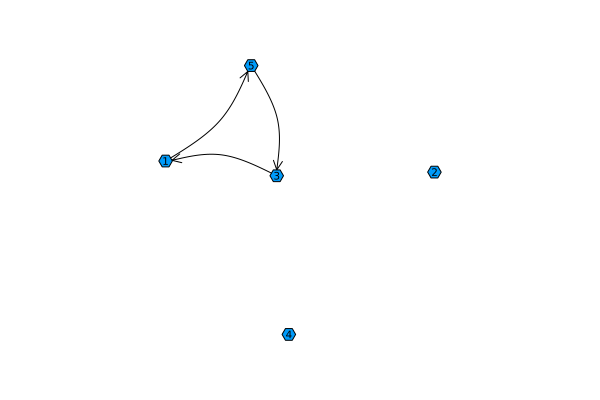

3-element Vector{Any}:
 (1, 5)
 (3, 1)
 (5, 3)

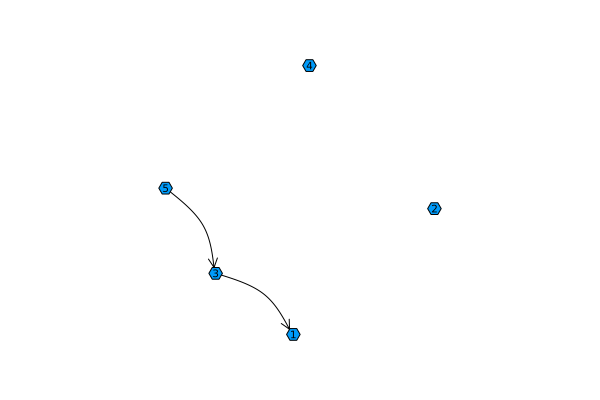

3-element Vector{Vector{Int64}}:
 [1, 5, 3]
 [2]
 [4]

Any[]

Any[]

In [7]:
display(soln_matrix)
display(round.(Int, soln_matrix))
testgraph = DiGraph(soln_matrix)
display(graphplot(soln_matrix, names = 1:5))
#collect(edges(soln_matrix))
#collectedge(soln_matrix)
collectedge1 = collect(edges(testgraph))
#print(collectedge)
#is_directed(testgraph)
#typeof(collectedge)
edgelist = []
for edge in collectedge1
     push!(edgelist,(src(edge),dst(edge)))
end
display(edgelist)

#edgelist[1][2]

#size(soln_matrix)[1]
testgraph

dfstree = dfs_tree(testgraph, 5)
display(graphplot(dfstree, names = 1:5))

collectedge2 = collect(edges(dfstree))
#print(collectedge)
#is_directed(testgraph)
#typeof(collectedge)
edgelist = []
for edge in collectedge2
     push!(edgelist,(src(edge),dst(edge)))
end
#display(edgelist)
#bfs_parents(testgraph)
componentlist = strongly_connected_components(testgraph)
#push!(componentlist,[4,2,3])
display(componentlist)#simplecycles_limited_length(testgraph, 6, ceiling=10^6)
#display(simplecycles(testgraph))
component_container = []
for component in componentlist
     includes_null = 0
     if length(component) <= 1
          continue
     elseif length(component) == 2
          push!(component_container, component)
          continue
     else
          for elmt in component
               if elmt == 5
                    includes_null = 1
               end
          end
     end
     if includes_null != 1
          push!(component_container, component)
     end
end
edge_container = []
for component in component_container
     edge_set = []
     for elmt in component
          for edge in collectedge1
               if src(edge) == elmt #|| dst(edge) == elmt
                    push!(edge_set,(src(edge),dst(edge)))
               end
          end
     end
     push!(edge_container, edge_set)
end

display(component_container)
display(edge_container)

#for index in component_container

#forbidden_tours()

In [8]:
#tabu_lists = [[0,0]]
#push!(tabu_lists, [0,3])
#display(soln_matrix)
#tabu_lists[1] = [1,2]
#tabu_lists



 #display(selected_edges(soln_matrix,5))

subtour([(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,9),(9,10)],9)

1-element Vector{Int64}:
 4

In [9]:
Iterators.product([1,2,3,4,5],[1,2,3,4,5])

Base.Iterators.ProductIterator{Tuple{Vector{Int64}, Vector{Int64}}}(([1, 2, 3, 4, 5], [1, 2, 3, 4, 5]))

In [10]:
cycle
S
hi
#:hi
#print(con)

UndefVarError: UndefVarError: `cycle` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [11]:
status

CALLBACK_NODE_STATUS_FRACTIONAL::CallbackNodeStatusCode = 1

In [12]:
display(graphplot(graphh, names = 1:5))

UndefVarError: UndefVarError: `graphh` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [15]:
display(con)
all_constraints(pairs_trading_model)

ScalarConstraint{AffExpr, MathOptInterface.LessThan{Float64}}(x[2,3] + x[3,4] + x[4,2], MathOptInterface.LessThan{Float64}(2.0))

UndefVarError: UndefVarError: `pairs_trading_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.